In [27]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
from nucleoid_detection.loaders import _collect_h5_datasets

def load_h5(filepath, dataset="image"):
    with h5py.File(filepath, "r") as h5f:
        # List available datasets
        datasets = _collect_h5_datasets(h5f)
        selected_dataset = None
        for _dataset in datasets:
            if _dataset.strip().split("/")[-1].lower() == dataset.lower():
                selected_dataset = _dataset
        
        if selected_dataset is None:
            raise Exception("Requested dataset not found")

        # Select the "Image" dataset
        ds = h5f[selected_dataset]
        print(f"Shape: {ds.shape}, dtype: {ds.dtype}")
        data = np.array(ds)

        return data

# Load the H5 file
filepath = "/Users/satusky/Desktop/044a_A_001_decon.h5"  # <-- update with your H5 file path
data = load_h5(filepath)


Shape: (3, 1, 7, 4840, 4840), dtype: float32


In [28]:
data = data.sum(axis=2).squeeze(axis=1)
data.shape

(3, 4840, 4840)

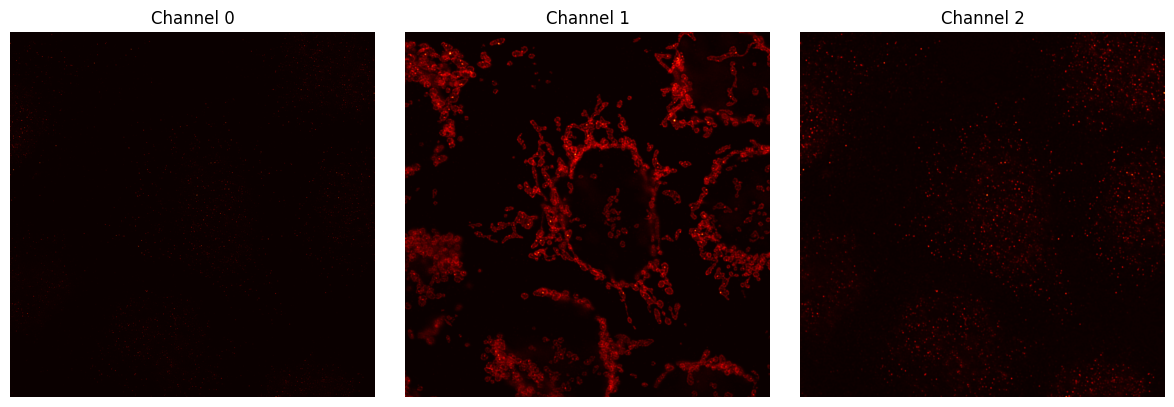

In [29]:
# Display all frames of the dataset
n_frames = data.shape[0]
cols = min(n_frames, 5)
rows = int(np.ceil(n_frames / cols))

fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows), squeeze=False)
for i in range(n_frames):
    ax = axes[i // cols, i % cols]
    ax.imshow(data[i], cmap="hot")
    ax.set_title(f"Channel {i}")
    ax.axis("off")

# Hide unused axes
for i in range(n_frames, rows * cols):
    axes[i // cols, i % cols].axis("off")

plt.tight_layout()
plt.show()

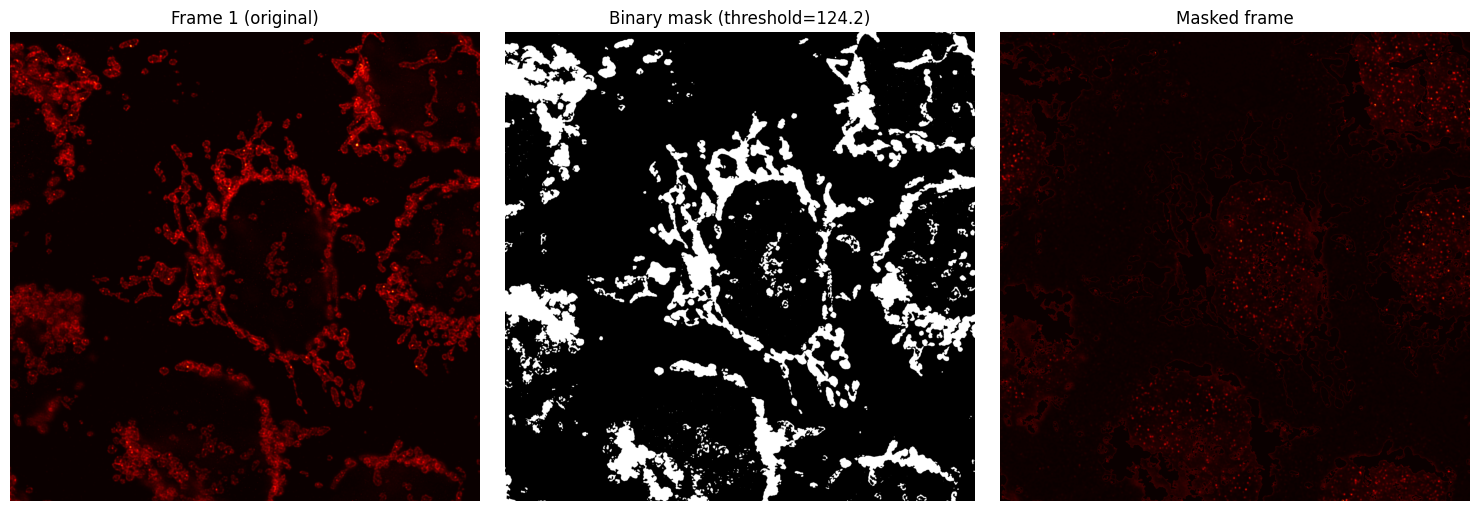

In [30]:
# Create a binary mask from one frame using Otsu thresholding
from skimage.filters import threshold_otsu
from skimage.morphology import remove_small_holes

mask_frame_idx = 1  # <-- change to select which frame to use for the mask
mask_frame = data[mask_frame_idx].astype(float)
mask_frame = data[0:2].sum(axis=0).astype(float)

thresh = threshold_otsu(mask_frame)
mito_mask = mask_frame > thresh
mito_mask = remove_small_holes(mito_mask, connectivity=2, max_size=10000)

masked = data.sum(axis=0) * ~mito_mask
masked -= masked.min()
masked /= masked.max()

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(mask_frame, cmap="hot")
axes[0].set_title(f"Frame {mask_frame_idx} (original)")
axes[1].imshow(mito_mask, cmap="gray")
axes[1].set_title(f"Binary mask (threshold={thresh:.1f})")
axes[2].imshow(masked, cmap="hot")
axes[2].set_title("Masked frame")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

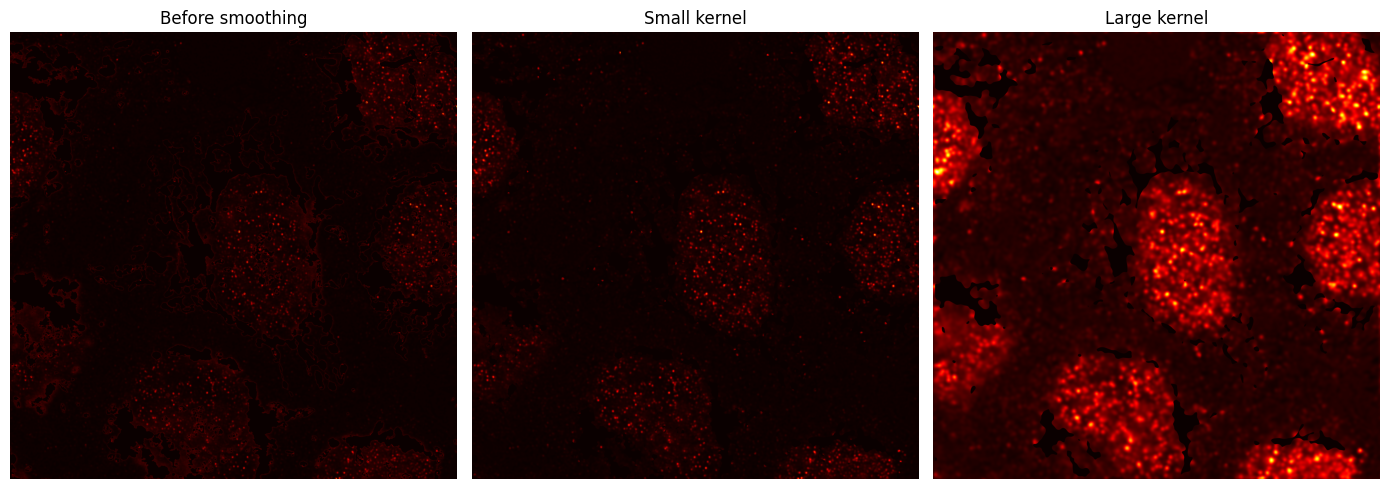

In [31]:
# Apply a 2D Gaussian blur to the result using nucleoid_detection
from nucleoid_detection import img_smooth_mask

px = 15e-9
im_sm = img_smooth_mask(data[0] + data[2], ~mito_mask, 0.15e-6 / px)
im_bg = img_smooth_mask(data[0] + data[2], ~mito_mask, 0.6e-6 / px)

fig, axes = plt.subplots(1, 3, figsize=(14, 6))
axes[0].imshow(masked, cmap="hot")
axes[0].set_title("Before smoothing")
axes[1].imshow(im_sm, cmap="hot")
axes[1].set_title(f"Small kernel")
axes[2].imshow(im_bg, cmap="hot")
axes[2].set_title(f"Large kernel")

for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

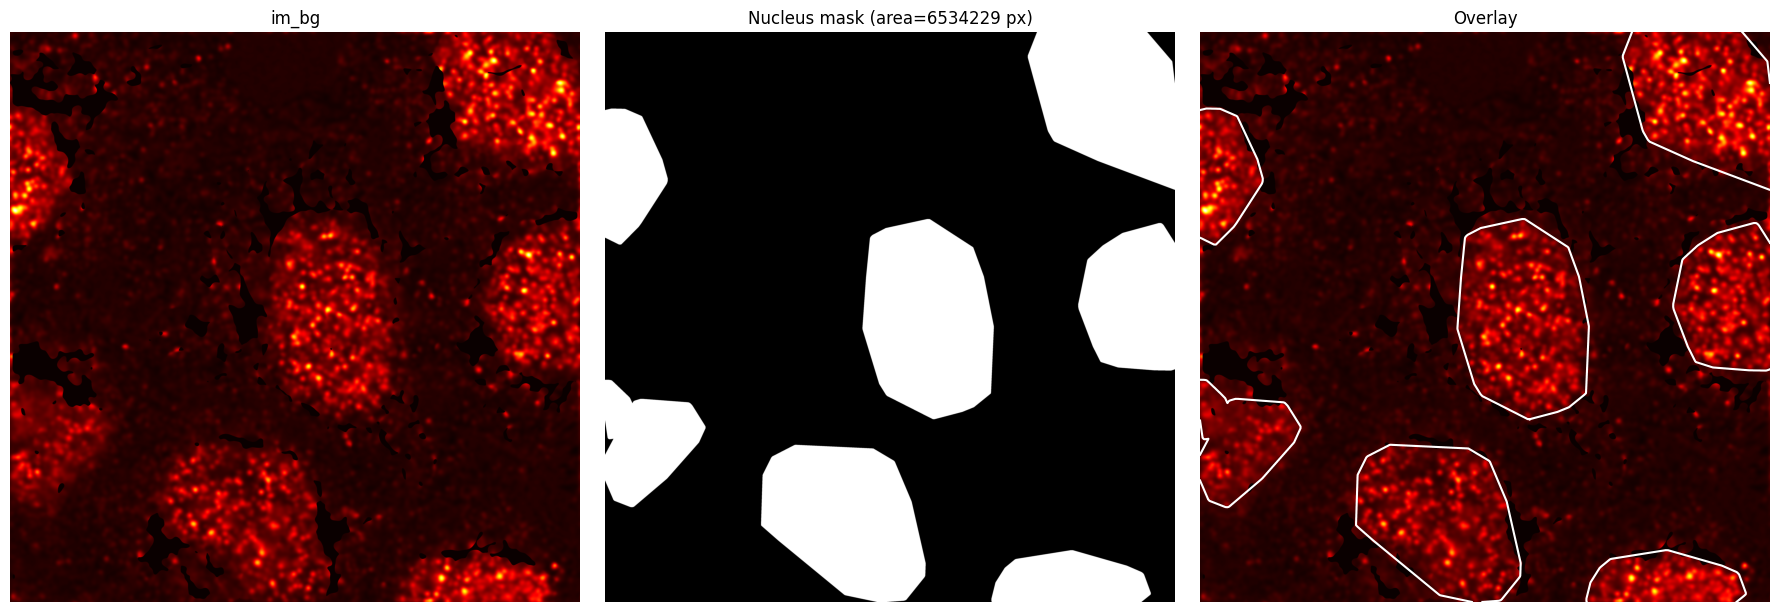

In [32]:
# Detect nucleus from im_bg
from nucleoid_detection import img_detect_nucleus
from skimage.measure import find_contours

test_im = im_bg

params = {"pad": 20, "smooth": 30, "threshold": 0.15, "area": 30000}
nucleus, nucleus_area = img_detect_nucleus(test_im, params)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
axes[0].imshow(test_im, cmap="hot")
axes[0].set_title("im_bg")
axes[1].imshow(nucleus, cmap="gray")
axes[1].set_title(f"Nucleus mask (area={nucleus_area:.0f} px)")
axes[2].imshow(test_im, cmap="hot")
contours = find_contours(nucleus.astype(float), 0.5)
for contour in contours:
    axes[2].plot(contour[:, 1], contour[:, 0], "w", linewidth=1.5)
axes[2].set_title("Overlay")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

Detected 560 spots
Fitted 560 spots


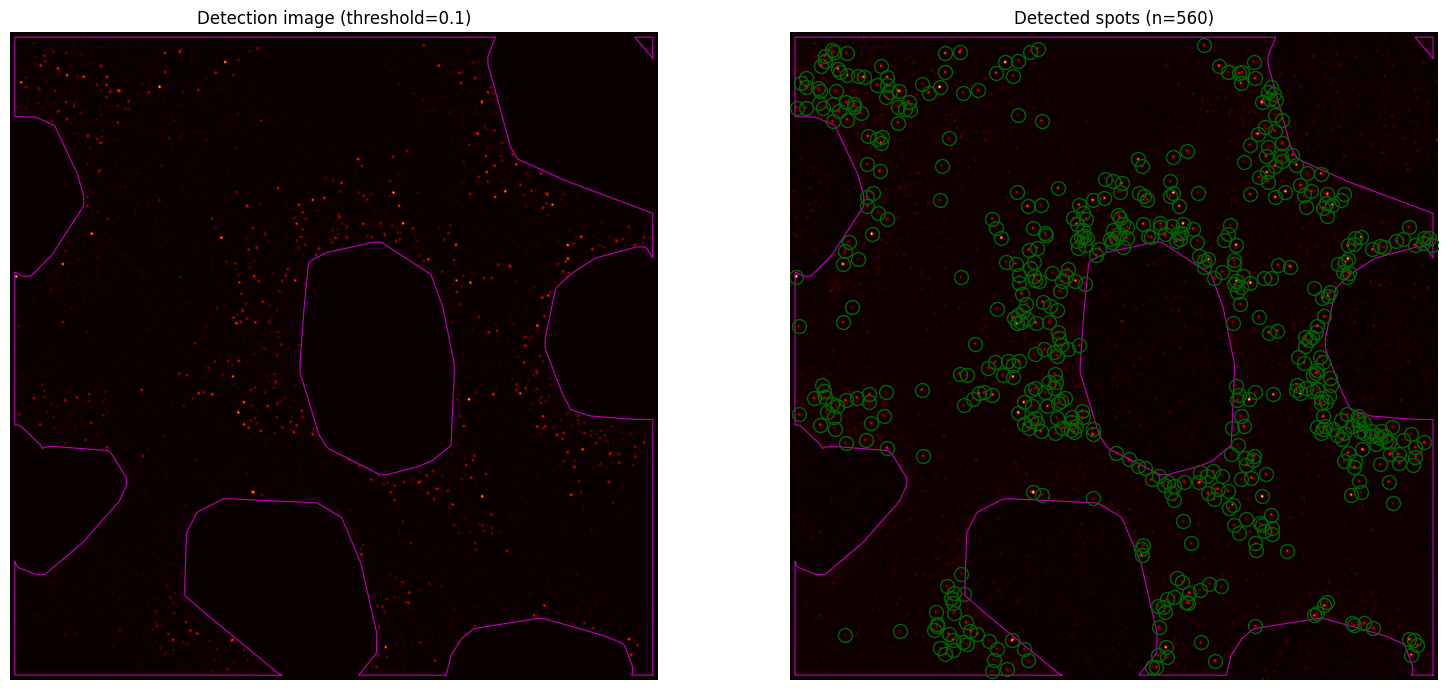

In [ ]:
# Detect nucleoid spots in data[2] using the nucleus mask
from nucleoid_detection import prepare_image, omex_local_max, fit_nucleoids

threshold = 0.1  # detection threshold
fwhm_nm = 100    # expected spot FWHM in nm

# Prepare image: background subtraction and object mask
im, det_data, obj = prepare_image(data[2], nucleus, px)

# Find local maxima above threshold
R = [0, max(det_data.max(), 50)]
T = threshold * R[1] + (1 - threshold) * R[0]
_, vi, xi, yi = omex_local_max(det_data, "max", 8, T)

# Keep only spots inside the object mask
if len(xi) > 0:
    m = obj[xi, yi]
    xi, yi = xi[m], yi[m]

print(f"Detected {len(xi)} spots")

# Fit Gaussian peaks
fwhmp = (fwhm_nm * 1e-9) / px
spots = fit_nucleoids(xi.astype(int), yi.astype(int), data[2], fwhmp)
spots[:, [4, 9, 10]] *= px
spots = np.column_stack([xi, yi, spots])
print(f"Fitted {len(spots)} spots")

# Display
contours = find_contours(obj.astype(float), 0.5)
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

axes[0].imshow(det_data, cmap="hot")
axes[0].set_title(f"Detection image (threshold={threshold})")
for contour in contours:
    axes[0].plot(contour[:, 1], contour[:, 0], "m", linewidth=0.8)

axes[1].imshow(im, cmap="hot", vmin=0, vmax=0.7 * im.max())
axes[1].set_title(f"Detected spots (n={len(xi)})")
for contour in contours:
    axes[1].plot(contour[:, 1], contour[:, 0], "m", linewidth=0.8)
if len(xi) > 0:
    marker_size = round(150e-9 / px)
    axes[1].plot(yi, xi, "o", markersize=marker_size, color=[0, 0.4, 0],
                 markerfacecolor="none", markeredgewidth=1)

for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

In [ ]:
# 